# Analyse + pretraitement + visualisation + grille de points DATASET SOIL

# Bibliotheque

In [1]:
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import os
import requests
import zipfile
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.mask import mask
from shapely.geometry import mapping
import pyodbc
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder
from rasterio.transform import xy
from shapely.geometry import Point
from scipy.spatial import KDTree

# Chargement des contours + carte

In [2]:

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

data_dir = "data"
shp_path = os.path.join(data_dir, "ne_110m_admin_0_countries.shp")
zip_path = os.path.join(data_dir, "ne_countries.zip")

os.makedirs(data_dir, exist_ok=True)

if not os.path.exists(zip_path):

    r = requests.get(url)   
    with open(zip_path, "wb") as f:
        f.write(r.content)
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_dir)

data_dir = r"C:\\Users\melom\OneDrive\Desktop\Data mining\Old_dataset\Soil\HWSD2"
bil_path = os.path.join(data_dir, "HWSD2_RASTER\HWSD2.bil")
mdb_path = os.path.join(data_dir, "HWSD2.mdb")



<>:18: SyntaxWarning: invalid escape sequence '\H'
<>:18: SyntaxWarning: invalid escape sequence '\H'
C:\Users\melom\AppData\Local\Temp\ipykernel_28168\438275522.py:18: SyntaxWarning: invalid escape sequence '\H'
  bil_path = os.path.join(data_dir, "HWSD2_RASTER\HWSD2.bil")


# Fonction Clip (Algeria + Tunisia)

In [3]:

def download_naturalearth(output_folder="data"):

    """Download Natural Earth shapefile if not present"""
    os.makedirs(output_folder, exist_ok=True)
    shapefile_path = os.path.join(output_folder, "ne_110m_admin_0_countries.shp")

    if not os.path.exists(shapefile_path):
        print("Downloading Natural Earth shapefile...")

        url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
        
        zip_path = os.path.join(output_folder, "ne_countries.zip")

        r = requests.get(url)
        with open(zip_path, "wb") as f:
            f.write(r.content)

        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(output_folder)
        os.remove(zip_path)
        print(" Natural Earth shapefile downloaded and extracted.")
    else:
        print(" Natural Earth shapefile already available.")
    return shapefile_path


def clip_algeria_tunisia(shapefile_path, bil_path):

    
    world = gpd.read_file(shapefile_path)

    world["COUNTRY"] = world["COUNTRY"].str.strip().str.lower()
    north_africa = world[world["COUNTRY"].isin(["algeria", "tunisia"])]

    if north_africa.empty:
        raise ValueError("Algeria or Tunisia not found in shapefile.")
    print("Shapefiles for Algeria and Tunisia loaded.")

    # --- Read the raster and clip both countries ---
    raster = rasterio.open(bil_path)
    geoms = [mapping(geom) for geom in north_africa.geometry]

    out_image, out_transform = mask(raster, geoms, crop=True)
    out_meta = raster.meta.copy()
    out_meta.update({
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

    raster_data = out_image[0].astype(float)
    raster_data = np.where(raster_data == raster.nodata, np.nan, raster_data)
    print("Raster clipped to Algeria + Tunisia region.")

    return raster_data, out_meta, out_image, north_africa


In [4]:
shape_file = r"C:\\Users\melom\OneDrive\Desktop\Data mining\shp\alg_tun.shp"
world = gpd.read_file(shape_file)
print(world.columns)
raster_data, out_meta, out_image, north_africa = clip_algeria_tunisia(shape_file, bil_path)


Index(['GID_0', 'COUNTRY', 'geometry'], dtype='object')
Shapefiles for Algeria and Tunisia loaded.
Raster clipped to Algeria + Tunisia region.


# Lecture de la base de donnees .mdb

In [5]:
conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str)


df_smu = pd.read_sql("SELECT * FROM HWSD2_SMU;", conn)
df_layer = pd.read_sql("SELECT * FROM HWSD2_LAYERS;", conn)
conn.close()

 
unique_ids = np.unique(raster_data[~np.isnan(raster_data)])
df_smu = df_smu[df_smu['HWSD2_SMU_ID'].isin(unique_ids)]
print(f"Matched {len(df_smu)} SMUs for Algeria + Tunisia.")


C:\Users\melom\AppData\Local\Temp\ipykernel_28168\3294030297.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_smu = pd.read_sql("SELECT * FROM HWSD2_SMU;", conn)
C:\Users\melom\AppData\Local\Temp\ipykernel_28168\3294030297.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_layer = pd.read_sql("SELECT * FROM HWSD2_LAYERS;", conn)


Matched 385 SMUs for Algeria + Tunisia.


## Selection des features desirees

In [6]:

df_layer_d1 = df_layer[df_layer["LAYER"].str.upper() == "D1"].copy()

 
selected_features = [
    "HWSD2_SMU_ID", "LAYER",  # keep IDs for linking
    "COARSE", "SAND", "SILT", "CLAY",
    "TEXTURE_USDA", "TEXTURE_SOTER",
    "BULK", "REF_BULK", "ORG_CARBON", "PH_WATER",
    "TOTAL_N", "CN_RATIO", "CEC_SOIL", "CEC_CLAY", "CEC_EFF",
    "TEB", "BSAT", "ALUM_SAT", "ESP", "TCARBON_EQ",
    "GYPSUM", "ELEC_COND"
]

df_layer_d1 = df_layer_d1[selected_features]

# Count occurrences of each soil ID
id_counts = df_layer_d1['HWSD2_SMU_ID'].value_counts()

# Print summary
print("Top 10 most frequent HWSD2_SMU_IDs:")
print(id_counts.head(10))

# Show IDs that appear more than once
duplicates = id_counts[id_counts > 1]
print(f"Number of duplicated unique IDs: {len(duplicates)}")
print(duplicates.head(20))

example_id = duplicates.index[0]
print(f"\nExample duplicated HWSD2_SMU_ID: {example_id}")
print(df_layer_d1[df_layer_d1['HWSD2_SMU_ID'] == example_id])

Top 10 most frequent HWSD2_SMU_IDs:
HWSD2_SMU_ID
36137    12
36183    12
36103    12
36089    11
36075    10
36108    10
36112    10
10313    10
36018    10
36260    10
Name: count, dtype: int64
Number of duplicated unique IDs: 15105
HWSD2_SMU_ID
36137    12
36183    12
36103    12
36089    11
36075    10
36108    10
36112    10
10313    10
36018    10
36260    10
36001    10
36174     9
36109     9
36235     9
36182     9
36159     9
36187     9
36220     9
36007     9
36042     8
Name: count, dtype: int64

Example duplicated HWSD2_SMU_ID: 36137
        HWSD2_SMU_ID LAYER  COARSE  SAND  SILT  CLAY  TEXTURE_USDA  \
329077         36137    D1      22    51    26    23          10.0   
329084         36137    D1      21    56    20    24          10.0   
329091         36137    D1       8    39    30    31           5.0   
329098         36137    D1       6    41    29    30           5.0   
329105         36137    D1      13    35    32    33           5.0   
329112         36137    D1 

## Selection des lines (Algeria + Tunisia)

In [7]:
df_joined = pd.merge(
    df_smu[["HWSD2_SMU_ID"]],
    df_layer_d1,
    on="HWSD2_SMU_ID",
    how="inner"
)

print(f"{len(df_joined)} D1-layer soil units matched with raster.")

 
numeric_props = (
    df_joined.select_dtypes(include=[np.number])
    .columns.drop(["HWSD2_SMU_ID"], errors="ignore")
    .tolist()
)

numeric_features = df_joined.select_dtypes(include=[np.number]).columns

print("Shape:", df_joined.shape)
print("Columns:", df_joined.columns.tolist())

print("Min:", df_joined["HWSD2_SMU_ID"].min())
print("Max:", df_joined["HWSD2_SMU_ID"].max())



861 D1-layer soil units matched with raster.
Shape: (861, 24)
Columns: ['HWSD2_SMU_ID', 'LAYER', 'COARSE', 'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA', 'TEXTURE_SOTER', 'BULK', 'REF_BULK', 'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY', 'CEC_EFF', 'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM', 'ELEC_COND']
Min: 36
Max: 32050


# Data analysis + processing

## Valeurs manquantes


D'abord, on a commencé par afficher les valeurs manquantes pour chaque attribut et leur pourcentage. Puisque les valeurs manquantes n'étaient pas très importantes, on les a remplacées par la médiane.

In [8]:
print("\nMissing values per attribute (only those with missing data):")

missing_values = df_joined[numeric_features].isna().sum()
missing_values = missing_values[missing_values > 0]

if missing_values.empty:
    print("No missing values found in numeric attributes.")
else:
     
    missing_df = missing_values.to_frame("Missing Count")
    missing_df["Missing %"] = (missing_df["Missing Count"] / len(df_joined) * 100).round(2)
     
    display(missing_df.sort_values(by="Missing Count", ascending=False))

 
for col in numeric_features:
    if df_joined[col].isna().any():
        median_value = df_joined[col].median(skipna=True)
        # Remplacement sans "inplace" pour éviter le FutureWarning
        df_joined[col] = df_joined[col].fillna(median_value)
        print(f"Filled missing numeric values in '{col}' with median ({median_value:.3f})")

# Vérification finale
missing_values = df_joined[numeric_features].isna().sum()
missing_values = missing_values[missing_values > 0]

if missing_values.empty:
    print("\nNo missing values found in numeric attributes after median imputation.\n")
else:
    missing_df = missing_values.to_frame("Missing Count")
    missing_df["Missing %"] = (missing_df["Missing Count"] / len(df_joined) * 100).round(2)
    display(missing_df.sort_values(by="Missing Count", ascending=False))





Missing values per attribute (only those with missing data):


,Missing Count,Missing %
TEXTURE_USDA,19,2.21
REF_BULK,19,2.21


Filled missing numeric values in 'TEXTURE_USDA' with median (9.000)
Filled missing numeric values in 'REF_BULK' with median (1.710)

No missing values found in numeric attributes after median imputation.



## Metriques et statistiques

In [9]:
numeric_features = df_joined.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric features:', numeric_features)

summary_stats = df_joined[numeric_features].describe(percentiles=[0.25, 0.5, 0.75]).T
summary_stats["mode"] = [
    df_joined[col].mode().iloc[0] if not df_joined[col].mode().empty else np.nan
    for col in numeric_features
]
summary_stats = summary_stats.rename(columns={
    "25%": "Q1",
    "50%": "Median (Q2)",
    "75%": "Q3",
    "mean": "Mean",
    "min": "Min",
    "max": "Max",
    "std": "Std"
})

print("\nSummary Statistics (all numeric features):")
display(summary_stats)

# Use df_joined here to stay consistent
data_sample = df_joined.head(20)

n = len(numeric_features)
split_size = (n + 2) // 3
groups = [numeric_features[i:i + split_size] for i in range(0, n, split_size)]

for i, group in enumerate(groups, start=1):
    print(f"\nNumeric Columns {group}:\n")
    display(data_sample[group])

    

Numeric features: ['HWSD2_SMU_ID', 'COARSE', 'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA', 'BULK', 'REF_BULK', 'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY', 'CEC_EFF', 'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM', 'ELEC_COND']

Summary Statistics (all numeric features):


,count,Mean,Std,Min,Q1,Median (Q2),Q3,Max,mode
HWSD2_SMU_ID,861.0,20187.623693,14818.508224,36.0,1800.000,31844.000,31931.000,32050.000000,1514.000
COARSE,861.0,11.787456,10.006283,-9.0,4.000,9.000,18.000,46.000000,18.000
SAND,861.0,46.955865,16.134836,-9.0,40.000,47.000,55.000,90.000000,55.000
SILT,861.0,29.397213,9.079760,-9.0,26.000,30.000,36.000,53.000000,30.000
CLAY,861.0,21.203252,10.372562,-9.0,16.000,20.000,24.000,55.000000,20.000
TEXTURE_USDA,861.0,8.963995,2.403458,3.0,9.000,9.000,11.000,12.000000,9.000
BULK,861.0,1.318780,0.780874,-9.0,1.370,1.440,1.470,1.760000,1.420
REF_BULK,861.0,1.714797,0.130648,1.2,1.650,1.710,1.780,2.040000,1.710
ORG_CARBON,861.0,0.830069,0.968955,-9.0,0.589,0.697,1.136,7.326000,0.589
PH_WATER,861.0,7.449129,1.803727,-9.0,7.400,8.000,8.200,8.600000,8.200



Numeric Columns ['HWSD2_SMU_ID', 'COARSE', 'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA', 'BULK', 'REF_BULK']:



,HWSD2_SMU_ID,COARSE,SAND,SILT,CLAY,TEXTURE_USDA,BULK,REF_BULK
0,31816,11,40,41,19,9.0,1.47,1.69
1,31802,11,40,41,19,9.0,1.47,1.69
2,31802,9,25,53,22,7.0,1.46,1.73
3,32034,9,88,6,6,12.0,1.62,1.34
4,31978,9,88,6,6,12.0,1.62,1.34
5,32019,9,88,6,6,12.0,1.62,1.34
6,32037,6,90,5,5,12.0,1.48,1.28
7,32037,9,55,26,19,11.0,1.54,1.70
8,31996,9,88,6,6,12.0,1.62,1.34
9,31996,6,90,5,5,12.0,1.48,1.28



Numeric Columns ['ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY', 'CEC_EFF', 'TEB']:



,ORG_CARBON,PH_WATER,TOTAL_N,CN_RATIO,CEC_SOIL,CEC_CLAY,CEC_EFF,TEB
0,2.037,5.3,1.54,14.0,11,26,6.0,5.0
1,2.037,5.3,1.54,14.0,11,26,6.0,5.0
2,1.801,5.8,1.57,11.0,15,51,14.0,12.0
3,0.255,8.0,0.26,10.0,5,52,12.0,12.0
4,0.255,8.0,0.26,10.0,5,52,12.0,12.0
5,0.255,8.0,0.26,10.0,5,52,12.0,12.0
6,0.259,6.7,0.32,9.0,4,61,4.0,4.0
7,0.665,8.0,0.74,9.0,15,68,30.0,30.0
8,0.255,8.0,0.26,10.0,5,52,12.0,12.0
9,0.259,6.7,0.32,9.0,4,61,4.0,4.0



Numeric Columns ['BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM', 'ELEC_COND']:



,BSAT,ALUM_SAT,ESP,TCARBON_EQ,GYPSUM,ELEC_COND
0,47,21,1,0.0,0.1,0
1,47,21,1,0.0,0.1,0
2,65,26,3,0.0,0.1,0
3,100,0,2,5.8,0.1,0
4,100,0,2,5.8,0.1,0
5,100,0,2,5.8,0.1,0
6,89,0,3,0.0,0.1,0
7,100,0,1,3.8,0.2,1
8,100,0,2,5.8,0.1,0
9,89,0,3,0.0,0.1,0


## Boxplot + histogrammes 

## Outliers

D'abord, comme première étape, on a affiché pour chaque attribut le nombre d’outliers liés, leur pourcentage par rapport à l’ensemble du dataset, ainsi que l’intervalle min et max selon la norme IQR.

### Analyse des outliers

Après, pour vraiment détailler et déterminer s’il s’agit d’outliers réels ou non, nous avons affiché, pour chaque attribut, les outliers possibles ainsi que les quantiles de chaque outlier. De cette manière, nous pouvons savoir si ces outliers représentent réellement des valeurs erronées ou bien des valeurs authentiques.

In [11]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print("\nOutlier detection (IQR method) for numeric attributes:\n")

detailed_outliers = []
summary_stats = []

for col in numeric_props:
    data = df_joined[col].dropna()
    if data.empty:  
        continue  

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    # ✅ bornes normales
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Détection des outliers
    outliers = data[(data < lower_bound) | (data > upper_bound)]

    if outliers.empty:
        continue

    # === Tableau détaillé (chaque valeur unique + count)
    outlier_counts = outliers.value_counts().reset_index()
    outlier_counts.columns = ["Outlier Value", "Count"]

    for _, row in outlier_counts.iterrows():
        detailed_outliers.append({
            "Attribute": col,
            "Outlier Value": round(row["Outlier Value"], 3),
            "Count": int(row["Count"]),
            "Normal Min (Q1 - 1.5*IQR)": round(lower_bound, 3),
            "Normal Max (Q3 + 1.5*IQR)": round(upper_bound, 3),
            "Direction": "Below Min" if row["Outlier Value"] < lower_bound else "Above Max"
        })

    # === Tableau de synthèse des stats outliers
    summary_stats.append({
        "Attribute": col,
        "Total Outliers": len(outliers),
        "Outlier %": round((len(outliers) / len(data)) * 100, 2),
        "Mean (Outliers)": round(outliers.mean(), 3),
        "Min (Outliers)": round(outliers.min(), 3),
        "Max (Outliers)": round(outliers.max(), 3),
        "Normal Min (Q1 - 1.5*IQR)": round(lower_bound, 3),
        "Normal Max (Q3 + 1.5*IQR)": round(upper_bound, 3)
    })


# === DataFrames finaux
detailed_df = pd.DataFrame(detailed_outliers)
summary_df = pd.DataFrame(summary_stats)

if summary_df.empty:
    print("No outliers detected in numeric attributes.")
else:
    # Trier les tableaux
    detailed_df = detailed_df.sort_values(by=["Attribute", "Outlier Value"])
    summary_df = summary_df.sort_values(by="Outlier %", ascending=False)

    print("\nSummary of Outliers by Attribute:\n")
    display(summary_df.style.set_table_styles([
        {"selector": "th", "props": [("font-weight", "bold"), ("background-color", "#f2f2f200")]}
    ]).hide(axis="index"))

    print("\nDetailed Outlier Values (with counts and direction):\n")
    display(detailed_df.style.set_table_styles([
        {"selector": "th", "props": [("font-weight", "bold"), ("background-color", "#f2f2f200")]}
    ]).hide(axis="index"))


Outlier detection (IQR method) for numeric attributes:


Summary of Outliers by Attribute:



Attribute,Total Outliers,Outlier %,Mean (Outliers),Min (Outliers),Max (Outliers),Normal Min (Q1 - 1.5*IQR),Normal Max (Q3 + 1.5*IQR)
ELEC_COND,310,36.000000,4.045000,-9.000000,32.000000,1.000000,1.000000
CN_RATIO,155,18.000000,10.742000,-9.000000,24.000000,7.500000,11.500000
TEXTURE_USDA,154,17.890000,4.325000,3.000000,5.000000,6.000000,14.000000
CEC_SOIL,152,17.650000,18.362000,-9.000000,41.000000,7.000000,23.000000
BSAT,132,15.330000,58.000000,-9.000000,82.000000,82.500000,110.500000
CEC_EFF,128,14.870000,72.406000,-9.000000,143.000000,0.500000,60.500000
ESP,99,11.500000,37.384000,-9.000000,67.000000,-1.000000,7.000000
GYPSUM,80,9.290000,33.990000,-9.000000,57.600000,-4.200000,7.800000
REF_BULK,77,8.940000,1.770000,1.200000,2.040000,1.455000,1.975000
SAND,76,8.830000,33.684000,-9.000000,90.000000,17.500000,77.500000



Detailed Outlier Values (with counts and direction):



Attribute,Outlier Value,Count,Normal Min (Q1 - 1.5*IQR),Normal Max (Q3 + 1.5*IQR),Direction
ALUM_SAT,-9.000000,1,0.000000,0.000000,Below Min
ALUM_SAT,-5.000000,1,0.000000,0.000000,Below Min
ALUM_SAT,-4.000000,7,0.000000,0.000000,Below Min
ALUM_SAT,-3.000000,8,0.000000,0.000000,Below Min
ALUM_SAT,-1.000000,2,0.000000,0.000000,Below Min
ALUM_SAT,5.000000,1,0.000000,0.000000,Above Max
ALUM_SAT,6.000000,6,0.000000,0.000000,Above Max
ALUM_SAT,8.000000,1,0.000000,0.000000,Above Max
ALUM_SAT,9.000000,1,0.000000,0.000000,Above Max
ALUM_SAT,11.000000,3,0.000000,0.000000,Above Max


## Distribution des attributs categoriques


Missing values per categorical attribute (only those with missing data):
No missing values found in categorical attributes.


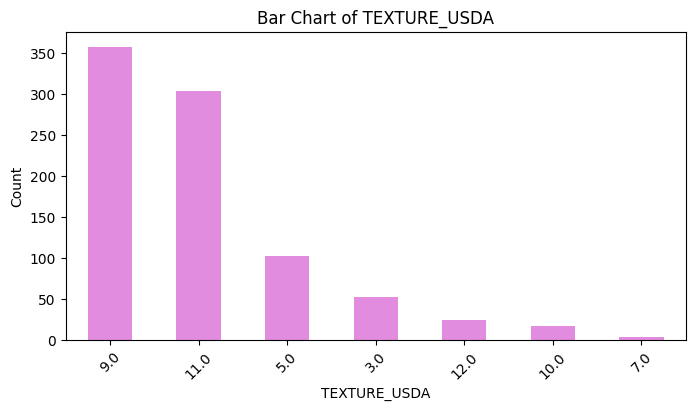

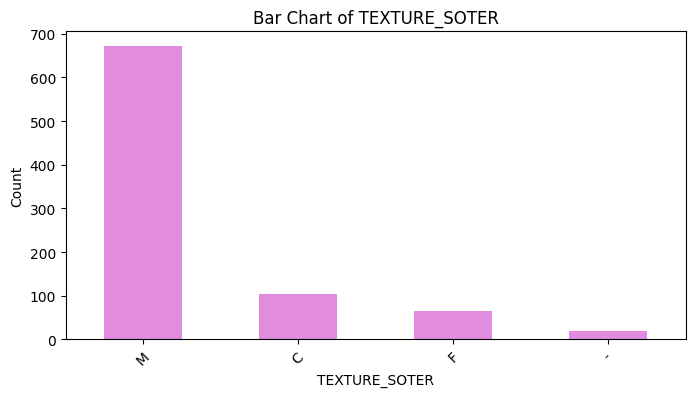

In [12]:
categorical_features = ["TEXTURE_USDA", "TEXTURE_SOTER"]

print("\nMissing values per categorical attribute (only those with missing data):")
missing_cat = df_joined[categorical_features].isna().sum()
missing_cat = missing_cat[missing_cat > 0]

if missing_cat.empty:
    print("No missing values found in categorical attributes.")
else:
    missing_cat_df = missing_cat.to_frame("Missing Count")
    missing_cat_df["Missing %"] = (missing_cat_df["Missing Count"] / len(df_joined) * 100).round(2)
    display(missing_cat_df.sort_values(by="Missing Count", ascending=False))

for col in categorical_features:
    plt.figure(figsize=(8, 4))
    df_joined[col].value_counts().plot(kind="bar", color="orchid", alpha=0.8)
    plt.title(f"Bar Chart of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

## Matrice de correlation + Scatter + Quantile plot

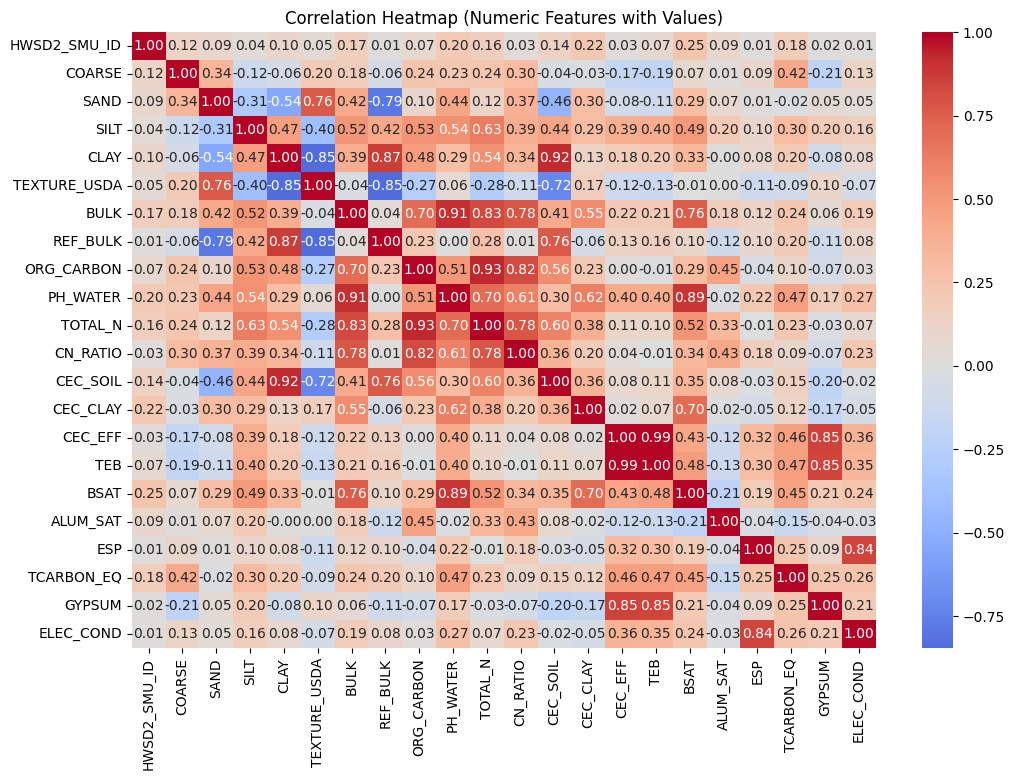


Strongly correlated feature pairs (|r| > 0.7):


,Feature1,Feature2,Correlation
3,SAND,TEXTURE_USDA,0.764660
7,CLAY,TEXTURE_USDA,-0.846682
8,CLAY,REF_BULK,0.868844
16,BULK,ORG_CARBON,0.703318
17,BULK,PH_WATER,0.909457
18,BULK,TOTAL_N,0.833690
19,BULK,CN_RATIO,0.777986
21,REF_BULK,SAND,-0.791192
23,REF_BULK,TEXTURE_USDA,-0.845452
28,ORG_CARBON,TOTAL_N,0.930771


In [13]:

 
corr_matrix = df_joined[numeric_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features with Values)")
plt.show()

 
threshold = 0.7
strong_corr_pairs = (
    corr_matrix.where(np.abs(corr_matrix) > threshold)
    .stack()
    .reset_index()
)
strong_corr_pairs.columns = ["Feature1", "Feature2", "Correlation"]
 
strong_corr_pairs = strong_corr_pairs[strong_corr_pairs["Feature1"] < strong_corr_pairs["Feature2"]]

print("\nStrongly correlated feature pairs (|r| > 0.7):")
display(strong_corr_pairs)




In [14]:
# Seuil de forte corrélation
threshold = 0.9

# Extraction des paires fortement corrélées
strong_corr_pairs = (
    corr_matrix.where(np.abs(corr_matrix) > threshold)
    .stack()
    .reset_index()
)
strong_corr_pairs.columns = ["Feature1", "Feature2", "Correlation"]

# Éviter les doublons (A-B et B-A)
strong_corr_pairs = strong_corr_pairs[strong_corr_pairs["Feature1"] < strong_corr_pairs["Feature2"]]

print("\nPaires de variables fortement corrélées (|r| > 0.9) :")
display(strong_corr_pairs)

# --- Étape suivante : liste des colonnes à supprimer ---
# On peut choisir arbitrairement de supprimer la deuxième colonne de chaque paire
to_drop = strong_corr_pairs["Feature2"].unique()

print("\nColonnes candidates à supprimer (corrélation > 0.9) :")
print(to_drop)


Paires de variables fortement corrélées (|r| > 0.9) :


,Feature1,Feature2,Correlation
8,BULK,PH_WATER,0.909457
11,ORG_CARBON,TOTAL_N,0.930771
17,CEC_SOIL,CLAY,0.922126
21,CEC_EFF,TEB,0.990933



Colonnes candidates à supprimer (corrélation > 0.9) :
['PH_WATER' 'TOTAL_N' 'CLAY' 'TEB']


## Supression des atrributs fortement correles

In [15]:
# Supprimer les colonnes fortement corrélées choisies
cols_to_drop = ['TEXTURE_USDA','LAYER']

df_cleaned = df_joined.drop(columns=cols_to_drop, errors='ignore')


## Jointure de la base de donnees + map

In [18]:
def plot_soil_property(numeric_props, raster_data, borders, df_joined):
    
    for prop in numeric_props:
        print(f"\n🔹 Generating map for: {prop}")

        lookup = dict(zip(df_joined['HWSD2_SMU_ID'], df_joined[prop]))
        prop_map = np.vectorize(lookup.get)(raster_data).astype(float)
        prop_map = np.ma.masked_invalid(prop_map)
        plt.figure(figsize=(12, 6))
        img = plt.imshow(prop_map, cmap="terrain")

        borders.boundary.plot(ax=plt.gca(), color="black", linewidth=1)
        plt.title(f"Algeria + Tunisia — HWSD2 {prop} (D1 layer, 0–20cm)", fontsize=14)
        plt.xlabel("Longitude (approx.)")
        plt.ylabel("Latitude (approx.)")

        plt.colorbar(img, fraction=0.03, pad=0.04, label=prop)
        plt.tight_layout()
        plt.show()



🔹 Generating map for: COARSE


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


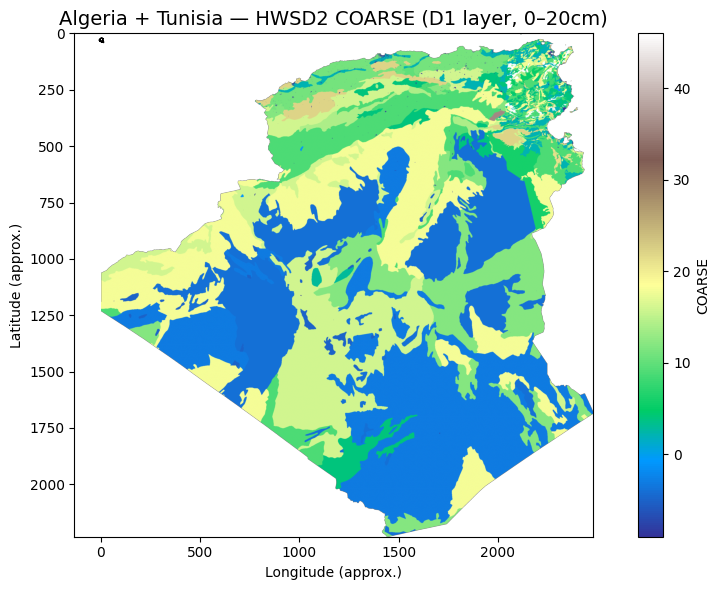


🔹 Generating map for: SAND


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


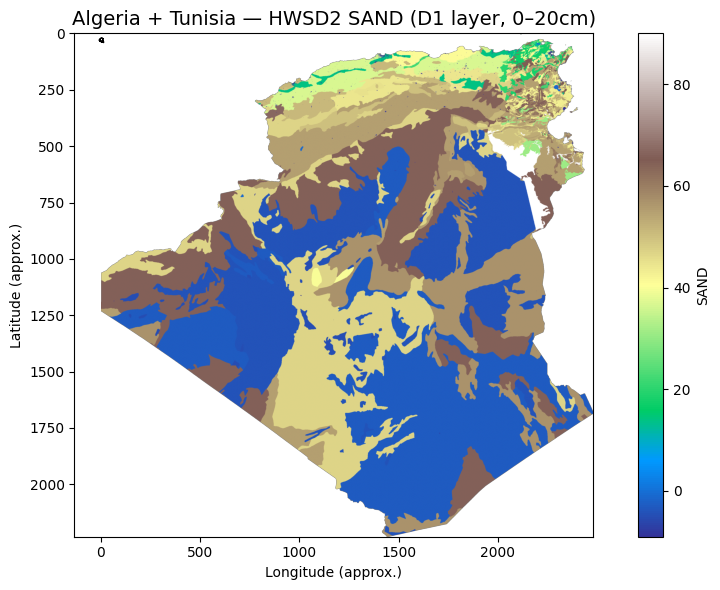


🔹 Generating map for: SILT


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


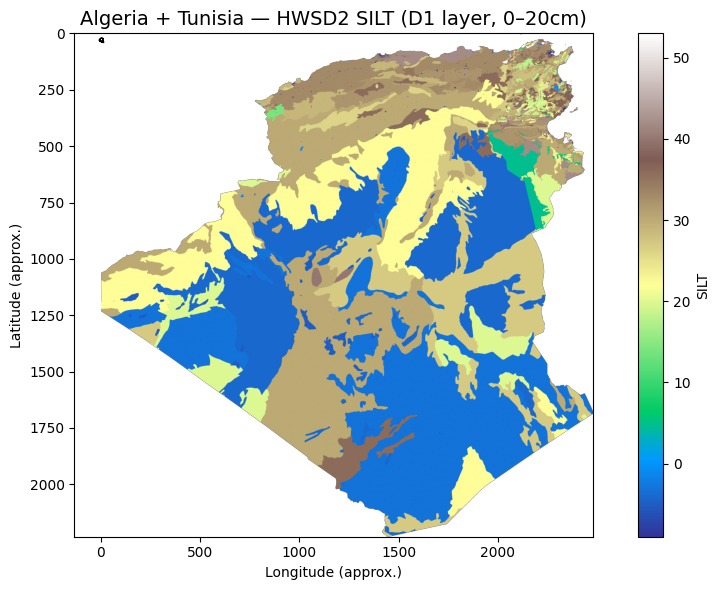


🔹 Generating map for: CLAY


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


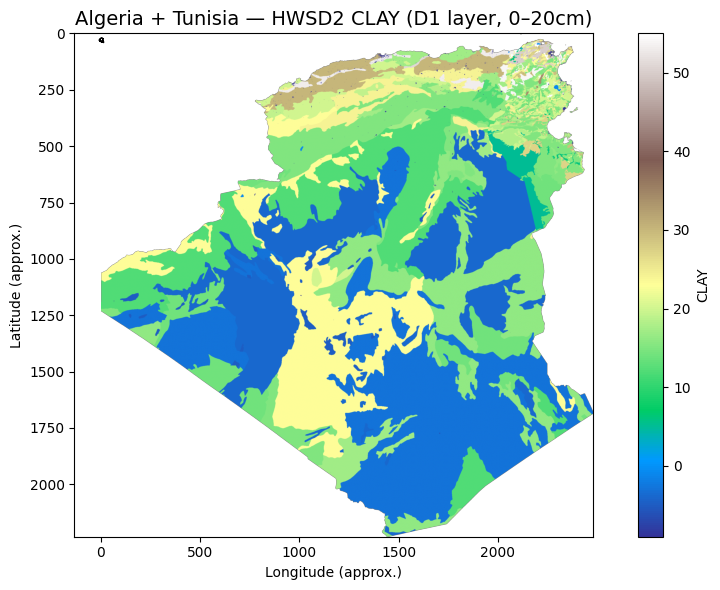


🔹 Generating map for: TEXTURE_USDA


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


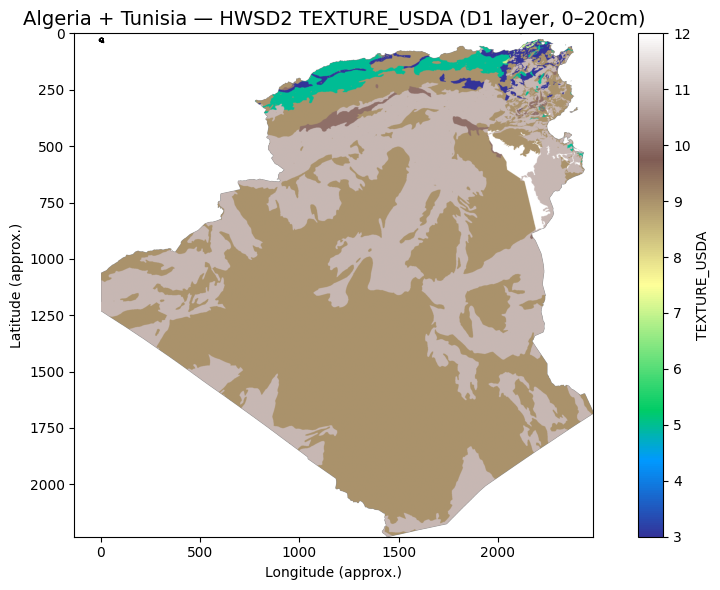


🔹 Generating map for: BULK


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


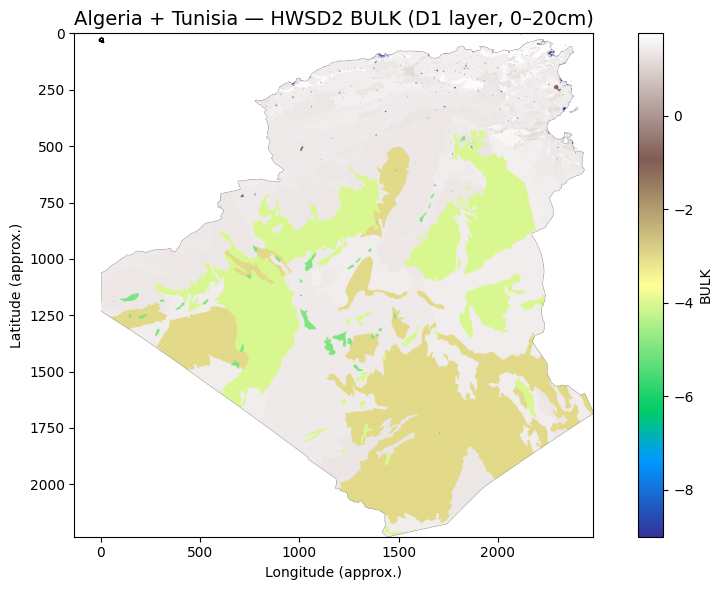


🔹 Generating map for: REF_BULK


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


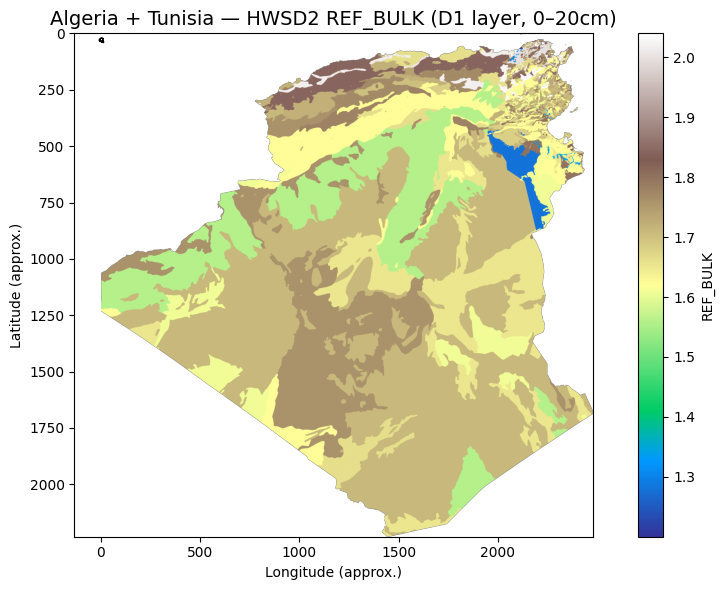


🔹 Generating map for: ORG_CARBON


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


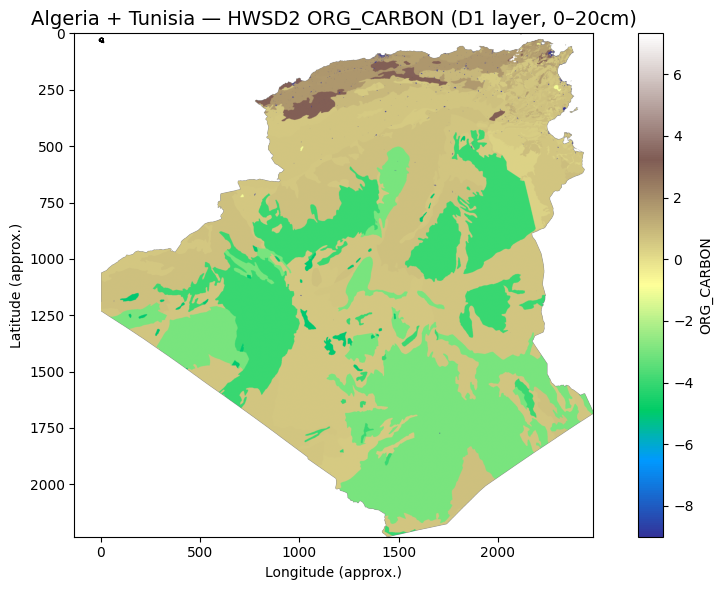


🔹 Generating map for: PH_WATER


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


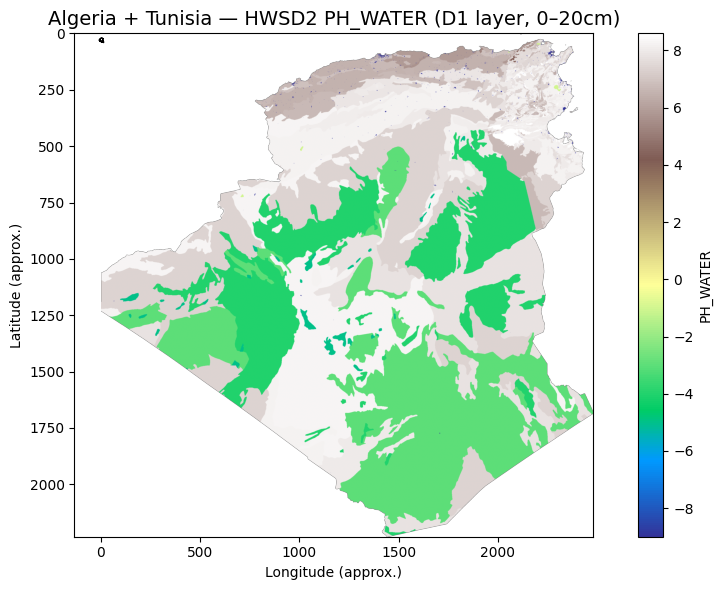


🔹 Generating map for: TOTAL_N


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


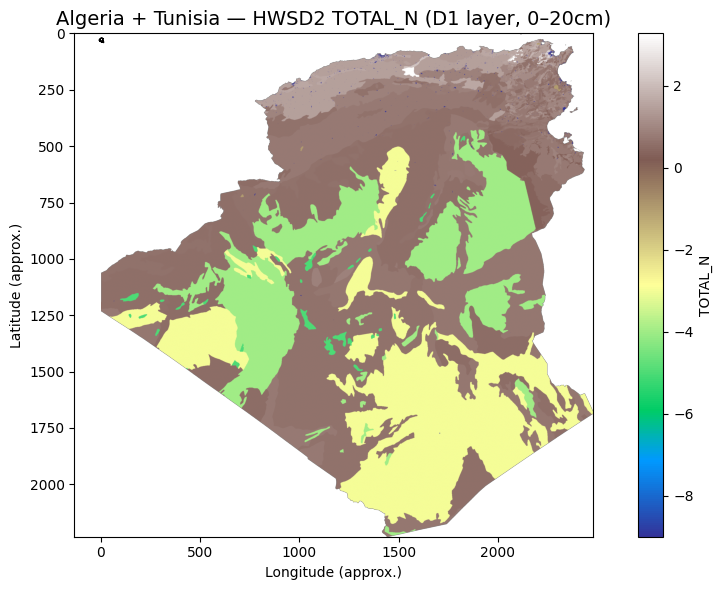


🔹 Generating map for: CN_RATIO


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


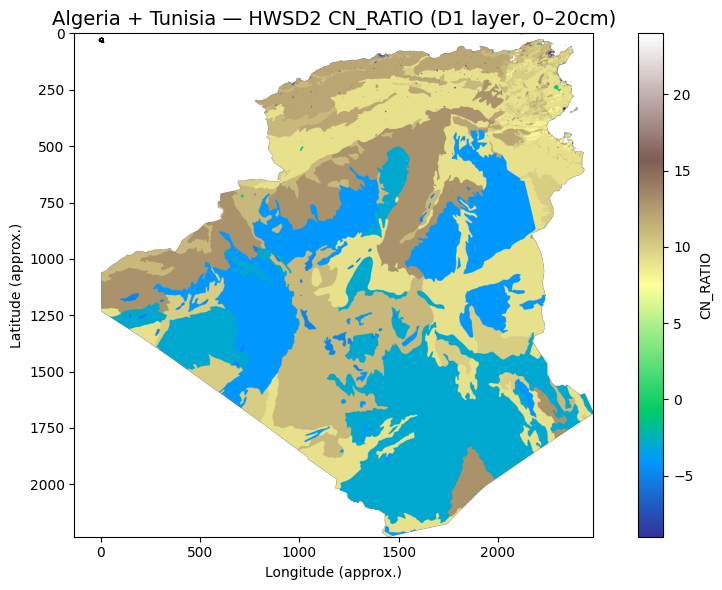


🔹 Generating map for: CEC_SOIL


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


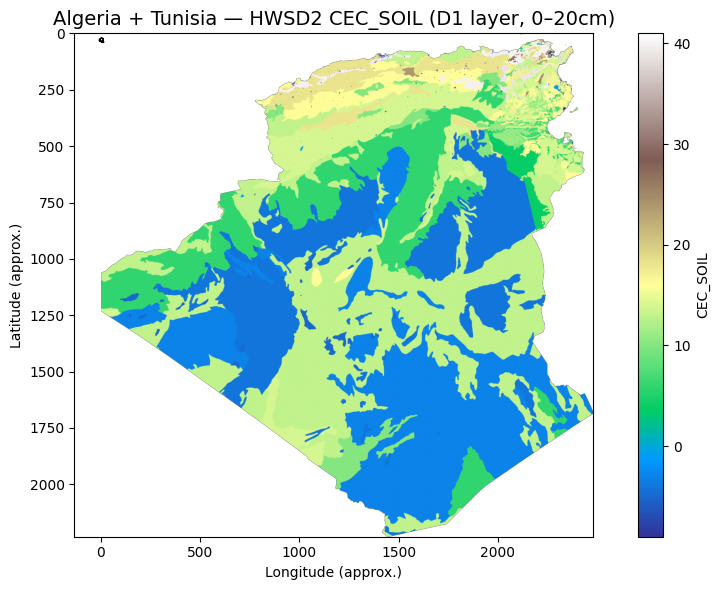


🔹 Generating map for: CEC_CLAY


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


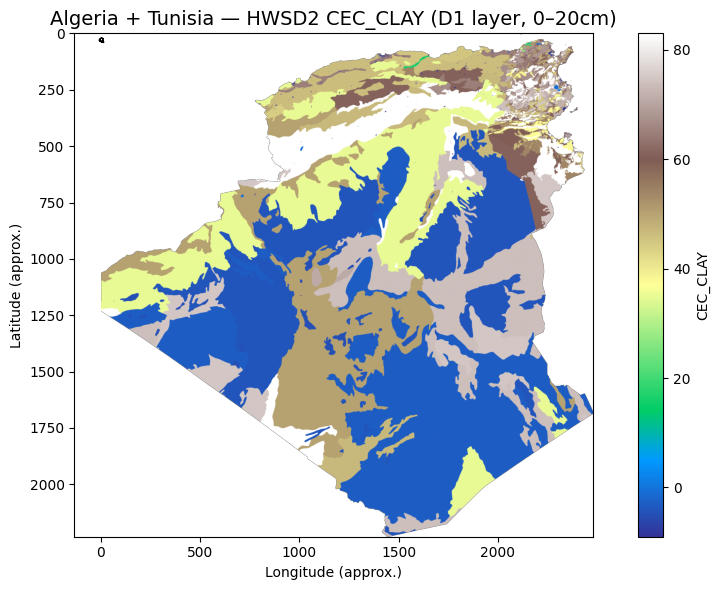


🔹 Generating map for: CEC_EFF


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


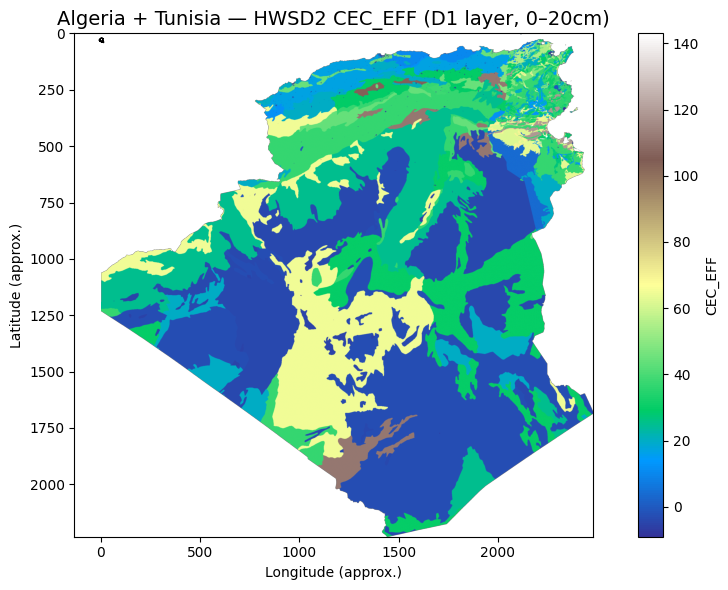


🔹 Generating map for: TEB


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


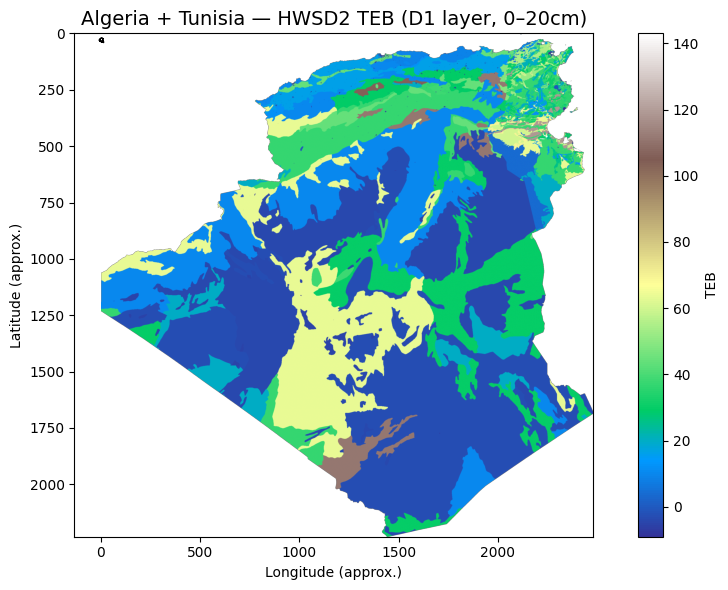


🔹 Generating map for: BSAT


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


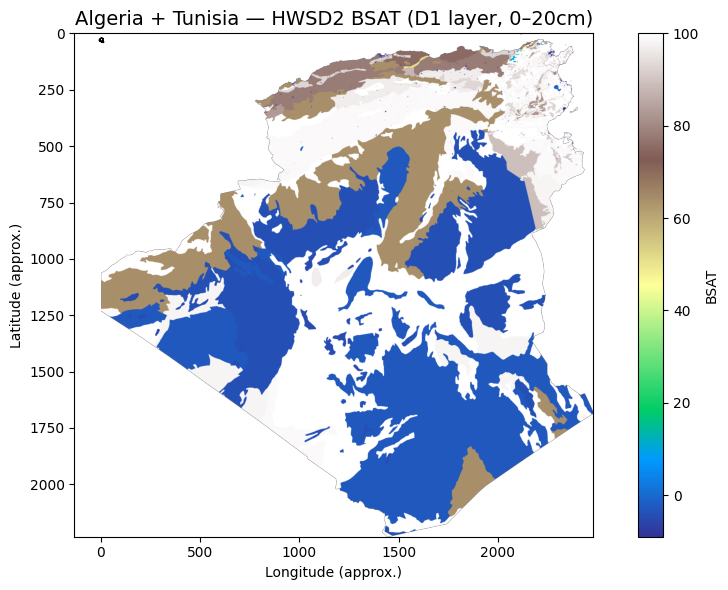


🔹 Generating map for: ALUM_SAT


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


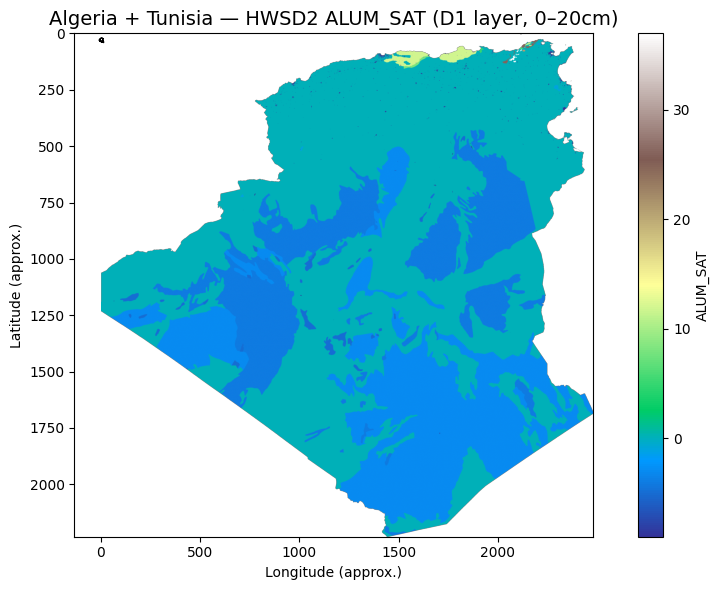


🔹 Generating map for: ESP


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


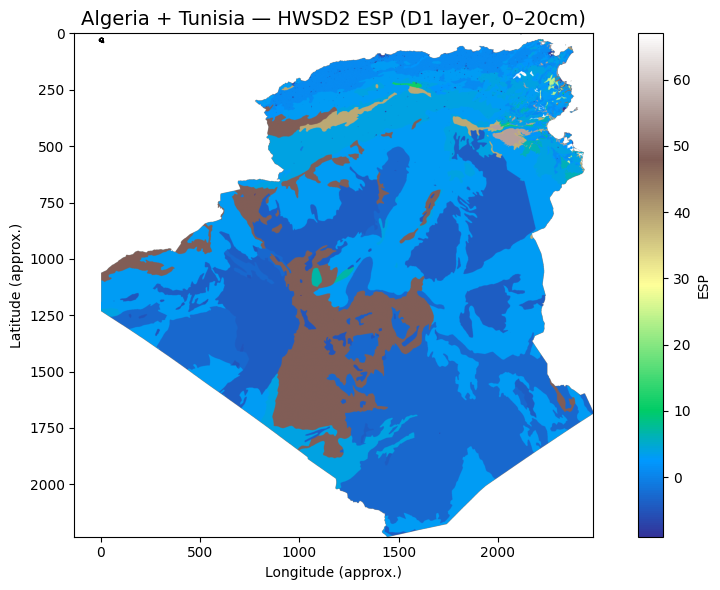


🔹 Generating map for: TCARBON_EQ


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


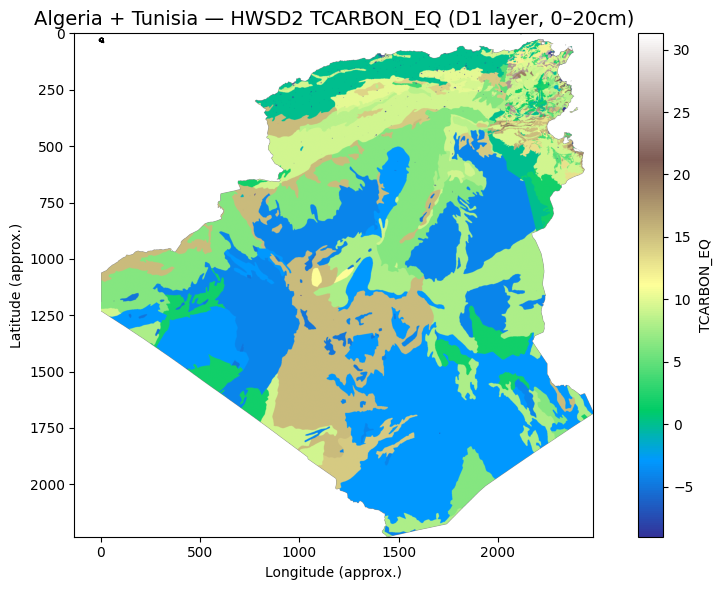


🔹 Generating map for: GYPSUM


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


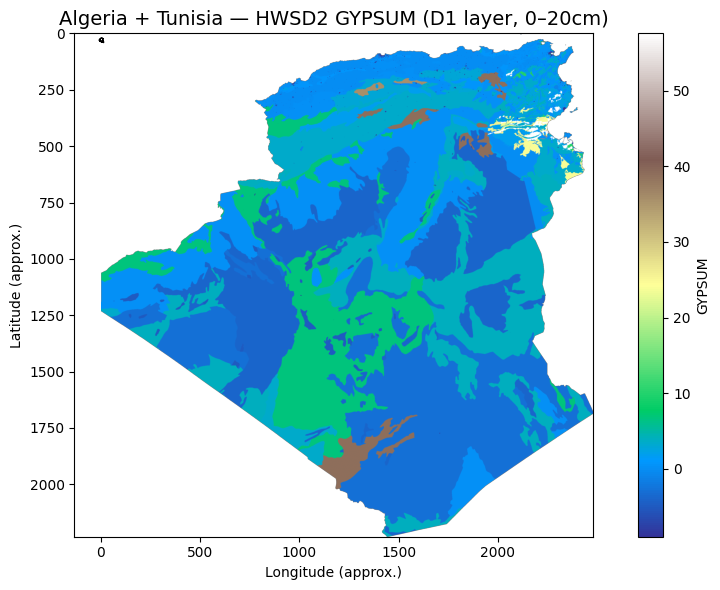


🔹 Generating map for: ELEC_COND


c:\Users\melom\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in get (vectorized)
  outputs = ufunc(*args, out=...)


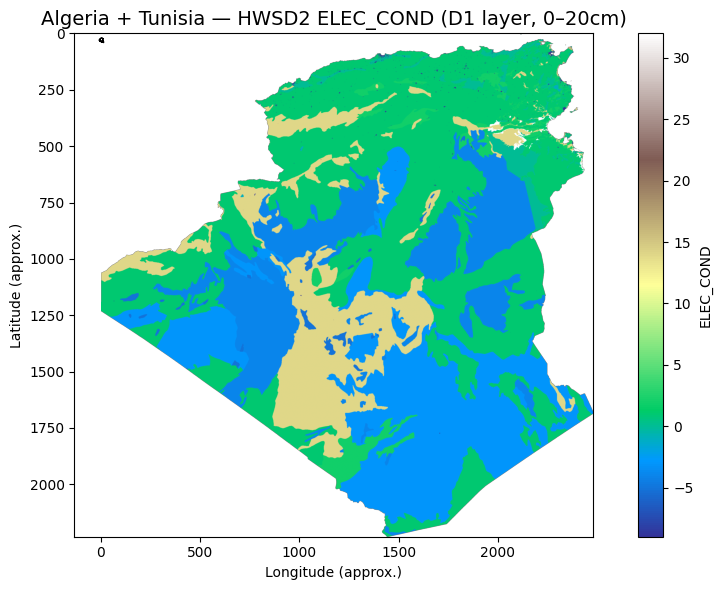

In [19]:
plot_soil_property(numeric_props, raster_data, north_africa, df_joined)

# Extraction de latitude et longitude pour chaque point avec scaling

In [20]:

grid_csv_path = "Cleaned_dataset/grid/algeria_tunisia_grid.csv"
output_csv_path = "Cleaned_dataset/grid/soil_grid.csv"


grid_df = pd.read_csv(grid_csv_path)

# Ensure longitude/latitude columns exist
lon_col = 'longitude' if 'longitude' in grid_df.columns else 'lon'
lat_col = 'latitude' if 'latitude' in grid_df.columns else 'lat'


with rasterio.open(bil_path) as src:
    coords = [(x, y) for x, y in zip(grid_df[lon_col], grid_df[lat_col])]
    smu_ids = list(src.sample(coords))
    smu_ids = np.array(smu_ids).squeeze()
    grid_df['HWSD2_SMU_ID'] = smu_ids


merged_df = pd.merge(
    grid_df,
    df_cleaned,
    on="HWSD2_SMU_ID",
    how="left"
)


In [21]:
print(f"Merged grid shape: {merged_df.shape}")

matched = merged_df['HWSD2_SMU_ID'].notna().sum()
total = len(merged_df)
print(f"Matched {matched}/{total} grid points ({matched/total:.1%}).")

merged_df.to_csv(output_csv_path, index=False)
print(f"Saved merged grid with soil properties to {output_csv_path}")

Merged grid shape: (211489, 24)
Matched 211489/211489 grid points (100.0%).
Saved merged grid with soil properties to Cleaned_dataset/grid/soil_grid.csv


In [22]:

missing_summary = (
    merged_df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "Column", 0: "Missing_Count"})
)

missing_summary["Missing_%"] = (
    missing_summary["Missing_Count"] / len(merged_df) * 100
).round(2)


missing_summary = missing_summary.sort_values("Missing_%", ascending=False)

print("Missing values per column:")
print(missing_summary.to_string(index=False))


Missing values per column:
       Column  Missing_Count  Missing_%
    longitude              0        0.0
     latitude              0        0.0
 HWSD2_SMU_ID              0        0.0
       COARSE              1        0.0
         SAND              1        0.0
         SILT              1        0.0
         CLAY              1        0.0
TEXTURE_SOTER              1        0.0
         BULK              1        0.0
     REF_BULK              1        0.0
   ORG_CARBON              1        0.0
     PH_WATER              1        0.0
      TOTAL_N              1        0.0
     CN_RATIO              1        0.0
     CEC_SOIL              1        0.0
     CEC_CLAY              1        0.0
      CEC_EFF              1        0.0
          TEB              1        0.0
         BSAT              1        0.0
     ALUM_SAT              1        0.0
          ESP              1        0.0
   TCARBON_EQ              1        0.0
       GYPSUM              1        0.0
    ELEC_COND

## Gestion des valeurs manquantes

### Remplacement des Outliers non coherrants (negatifs) par NaN

Selon plusieurs sources sur Internet, nous avons constaté que, dans un dataset, lorsque les valeurs –9, –5, –4, –3 ou –1 se répètent dans le tableau de données, elles sont souvent considérées comme équivalentes à des valeurs nulles, surtout lorsqu’un attribut ne peut pas avoir de valeur négative. Dans notre cas, nos attributs sont principalement liés à la Terre — comme la quantité d’aluminium, le sable ou la conductivité électrique — ce sont des variables qui ne peuvent pas prendre de valeurs négatives. Cela signifie que leur valeur ne peuvent pas etre inférieure à zéro.

In [23]:
print(merged_df.head())
print(merged_df.shape)

merged_df.to_csv(output_csv_path, index=False)
print(merged_df.shape)
print(f"Saved merged grid with soil properties to {output_csv_path}")

   longitude   latitude  HWSD2_SMU_ID  COARSE  SAND  SILT  CLAY TEXTURE_SOTER  \
0  -1.653868  34.000231          1767     3.0  40.0  40.0  20.0             M   
1  -1.653868  34.000231          1767    18.0  66.0  22.0  12.0             C   
2  -1.653868  34.000231          1767    12.0  57.0  27.0  16.0             M   
3  -1.653868  34.000231          1767    16.0  47.0  30.0  23.0             M   
4  -1.633868  34.000231          1767     3.0  40.0  40.0  20.0             M   

   BULK  REF_BULK  ORG_CARBON  PH_WATER  TOTAL_N  CN_RATIO  CEC_SOIL  \
0  1.49      1.71       0.695       8.2     0.92       9.0      16.0   
1  1.37      1.56       0.711       7.4     0.58      13.0       6.0   
2  1.43      1.65       0.616       7.8     0.73       9.0      13.0   
3  1.42      1.76       0.545       8.3     0.62      11.0      13.0   
4  1.49      1.71       0.695       8.2     0.92       9.0      16.0   

   CEC_CLAY  CEC_EFF   TEB   BSAT  ALUM_SAT   ESP  TCARBON_EQ  GYPSUM  \
0      

In [24]:
numeric_cols = ["COARSE","SAND","SILT","CLAY","BULK","REF_BULK","ORG_CARBON","PH_WATER","TOTAL_N","CN_RATIO","CEC_SOIL","CEC_CLAY","CEC_EFF","TEB","BSAT","ALUM_SAT",
                "ESP","TCARBON_EQ","GYPSUM","ELEC_COND",]

In [25]:
def correction_soil(csv_path, output_path, numeric_cols):

    df = pd.read_csv(csv_path)
 
    df = df.replace("-", np.nan)

    # Convert to numeric
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

    # Detect negative-value rows
    mask_negative = df[numeric_cols].lt(0).any(axis=1)

    # Compute duplicates per coordinate pair
    coord_cols = ["latitude", "longitude"]
    counts = df.groupby(coord_cols)[coord_cols[0]].transform("count")

    # Rows to delete and fix
    mask_delete = mask_negative & (counts > 1)
    mask_fix = mask_negative & (counts <= 1)

    rows_to_delete_count = mask_delete.sum()
    rows_to_fix_count = mask_fix.sum()
 
    df_clean = df.loc[~mask_delete].copy()

    # -------- FIX rows (replace only the negative values with NaN) -------- 
    idx_fix = df_clean.index.intersection(df.index[mask_fix])

    # Replace negatives with NaN in those rows
    df_clean.loc[idx_fix, numeric_cols] = df_clean.loc[idx_fix, numeric_cols].mask(
        df_clean.loc[idx_fix, numeric_cols] < 0
    )
    # ----------------------------------------------------------------------

    df_clean.to_csv(output_path, index=False)

    print("✔ Cleaning complete!")
    print(f"  Deleted rows : {rows_to_delete_count}")
    print(f"  Fixed rows   : {rows_to_fix_count}")

    return df_clean

In [26]:
clean_df = correction_soil(output_csv_path, output_csv_path, numeric_cols)

✔ Cleaning complete!
  Deleted rows : 0
  Fixed rows   : 771


### Traitement des valeurs NaN crees

Alors, nous avons remplacé ces valeurs négatives par des valeurs nulles, puis nous avons procédé au remplissage une fonction reparatrice. De cette façon, nous avons déjà réduit un nombre important d’outliers dans notre dataset.

Ce qu’il reste, selon notre première analyse — bien sûr non définitive —, ne justifie pas forcément l’élimination d’autres outliers, même si leur pourcentage reste relativement élevé. Nous avons donc décidé de les conserver pour l’instant et d’y revenir plus tard si nécessaire.

In [27]:
def impute_with_geo_zones(
    input_csv,
    num_cols=None,
    cat_cols=None,
    lat_col="latitude",
    lon_col="longitude",
    base_res=0.1,
    min_points=10,
    max_res=5.0,
    output_path=None,
):
    df = pd.read_csv(input_csv)
    num_cols = num_cols or []
    cat_cols = cat_cols or []

    # --- 1. Missing percentage ---
    missing_percent = df.isnull().mean() * 100
    print("Missing values (percent) per column :")
    print(missing_percent[missing_percent > 0])

    def impute_value(row, col, is_num, max_res):
        lat, lon = row[lat_col], row[lon_col]
        resolution = base_res

        while resolution <= max_res:
            lat_min, lat_max = lat - resolution, lat + resolution
            lon_min, lon_max = lon - resolution, lon + resolution

            # Vectorized filtering for the zone
            zone_df = df[
                (df[lat_col] >= lat_min)
                & (df[lat_col] <= lat_max)
                & (df[lon_col] >= lon_min)
                & (df[lon_col] <= lon_max)
            ]

            # Check the number of non-missing values in the target column
            valid_count = zone_df[col].count()

            if valid_count >= min_points:
                break
            resolution *= 1.5

        if valid_count == 0:  # Fallback to global
            print("Fallback to global , valid_count=0")
            return df[col].median() if is_num else df[col].mode(dropna=True).iat[0]

        if is_num:
            return zone_df[col].median()
        else:
            mode_val = zone_df[col].mode(dropna=True)
            return (
                mode_val.iat[0]
                if not mode_val.empty
                else df[col].mode(dropna=True).iat[0]
            )

    # --- 2. Process each column ---
    for col in df.columns:
        if col in [lat_col, lon_col] or missing_percent.get(col, 0) == 0:
            continue

        print(f"\n=== Imputing column: {col} ===")

        is_num = col in num_cols or (
            col not in cat_cols and pd.api.types.is_numeric_dtype(df[col])
        )

        # Select only the rows where the column is missing
        missing_rows = df[df[col].isnull()].copy()

        # Apply the imputation function to the missing rows
        imputed_values = missing_rows.apply(
            lambda row: impute_value(row, col, is_num, max_res), axis=1
        )

        # Assign the calculated values back to the original DataFrame
        df.loc[imputed_values.index, col] = imputed_values

        print(f"{col}: imputation done using geo-zones.")

    if output_path:
        df.to_csv(output_path, index=False)
        print(f"💾 Saved imputation to {output_path}")

    return df

In [28]:
clean_df = impute_with_geo_zones(
    output_csv_path,
    output_path=output_csv_path,
    cat_cols=['TEXTURE_SOTER']
)

Missing values (percent) per column :
COARSE           0.365031
SAND             0.365031
SILT             0.365031
CLAY             0.365031
TEXTURE_SOTER    0.365031
BULK             0.365031
REF_BULK         0.000473
ORG_CARBON       0.365031
PH_WATER         0.365031
TOTAL_N          0.365031
CN_RATIO         0.365031
CEC_SOIL         0.365031
CEC_CLAY         0.365031
CEC_EFF          0.365031
TEB              0.365031
BSAT             0.365031
ALUM_SAT         0.365031
ESP              0.365031
TCARBON_EQ       0.365031
GYPSUM           0.365031
ELEC_COND        0.365031
dtype: float64

=== Imputing column: COARSE ===
COARSE: imputation done using geo-zones.

=== Imputing column: SAND ===
SAND: imputation done using geo-zones.

=== Imputing column: SILT ===
SILT: imputation done using geo-zones.

=== Imputing column: CLAY ===
CLAY: imputation done using geo-zones.

=== Imputing column: TEXTURE_SOTER ===
TEXTURE_SOTER: imputation done using geo-zones.

=== Imputing column: BULK ==

In [29]:
missing_summary = (
    clean_df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "Column", 0: "Missing_Count"})
)

missing_summary["Missing_%"] = (
    missing_summary["Missing_Count"] / len(clean_df) * 100
).round(2)


missing_summary = missing_summary.sort_values("Missing_%", ascending=False)

print("Missing values per column:")
print(missing_summary.to_string(index=False))


Missing values per column:
       Column  Missing_Count  Missing_%
    longitude              0        0.0
     latitude              0        0.0
 HWSD2_SMU_ID              0        0.0
       COARSE              0        0.0
         SAND              0        0.0
         SILT              0        0.0
         CLAY              0        0.0
TEXTURE_SOTER              0        0.0
         BULK              0        0.0
     REF_BULK              0        0.0
   ORG_CARBON              0        0.0
     PH_WATER              0        0.0
      TOTAL_N              0        0.0
     CN_RATIO              0        0.0
     CEC_SOIL              0        0.0
     CEC_CLAY              0        0.0
      CEC_EFF              0        0.0
          TEB              0        0.0
         BSAT              0        0.0
     ALUM_SAT              0        0.0
          ESP              0        0.0
   TCARBON_EQ              0        0.0
       GYPSUM              0        0.0
    ELEC_COND

In [30]:
clean_df.to_csv(output_csv_path, index=False)
print(f"Saved merged grid with soil properties to {output_csv_path}")

Saved merged grid with soil properties to Cleaned_dataset/grid/soil_grid.csv
